### Setting up a new kpms project

In [ ]:
import keypoint_moseq as kpms
import os

data_dir = '/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2024/3cham_wanhui/kpms-3cham/dlc/' #where your dlc data is stored
project_dir = '/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2024/3cham_wanhui/kpms-3cham' #project directory
config = lambda: kpms.load_config(project_dir)
dlc_config = os.path.join(data_dir, 'config.yaml')
kpms.setup_project(project_dir, deeplabcut_config=dlc_config, overwrite=True) #setting up dlc_config file

This line of code should create a project config file. 

### Loading data

In [ ]:
import keypoint_moseq as kpms
import os
project_dir = '/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2024/3cham_wanhui/kpms-3cham/'  #project directory
config = lambda: kpms.load_config(project_dir)

kp_data_path = '/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2024/3cham_wanhui/kpms-3cham/interpolated2' 
coordinates, confidences, bodyparts = kpms.load_keypoints(kp_data_path, 'deeplabcut')

data, metadata = kpms.format_data(coordinates, confidences, **config())

### Callibration

In [ ]:
%matplotlib widget
kpms.noise_calibration(project_dir, coordinates, confidences, **config())

### Visualization

#### Trajectory plots

In [ ]:
model_name = '2025_07_10-18_30_37'
results = kpms.load_results(project_dir, model_name)
kpms.generate_trajectory_plots(coordinates, 
                               results, 
                               project_dir, 
                               model_name, 
                               **config())

#### Grid movies

In [ ]:
model_name = '2025_07_10-18_30_37'
results = kpms.load_results(project_dir, model_name)
kpms.generate_grid_movies(results= results, 
                          project_dir = project_dir, 
                          model_name = model_name, 
                          coordinates=coordinates, 
                          dot_color=(0, 0, 255),
                          rows = 2, 
                          cols = 10, 
                          overlay_keypoints= True,
                          sampling_options={'mode':'density', 'n_neighbors':20},
                          **config());

#### Dendogram

In [ ]:
model_name = '2025_07_10-18_30_37'
results = kpms.load_results(project_dir, model_name)
kpms.plot_similarity_dendrogram(coordinates, 
                                results, 
                                project_dir, 
                                model_name, 
                                figsize=(10, 10),
                                **config())

### Asign groups 

In [ ]:
model_name = '2025_07_10-18_30_37'
results = kpms.load_results(project_dir, model_name)

In [ ]:
from keypoint_moseq.analysis_v2 import interactive_group_setting
interactive_group_setting(project_dir, model_name, num_factors = 1)

### Running statistics

New code for multiple factors:

In [ ]:
from keypoint_moseq.analysis_v2 import compute_moseq_df, compute_stats_df
moseq_df = compute_moseq_df(project_dir = project_dir, 
                            model_name= model_name, 
                            smooth_heading=True, 
                            num_factors=1)

In [ ]:
stats_df = compute_stats_df(
    project_dir,
    model_name,
    moseq_df,
    min_frequency=0.05,
    fps=30,
    num_factors=1,
)

Old code for a single factor: 

In [ ]:
from keypoint_moseq.analysis import compute_moseq_df, compute_stats_df
moseq_df = compute_moseq_df(project_dir = project_dir, 
                            model_name= model_name, 
                            smooth_heading=True)

In [28]:
moseq_df.to_csv(os.path.join(project_dir, model_name, '/Users/annateruel/Desktop/moseq_df.csv'), index=False)

In [9]:
stats_df = compute_stats_df(
    project_dir,
    model_name,
    moseq_df,
    min_frequency=0.01,
    fps=30,
)

In [ ]:
stats_df.to_csv(os.path.join(project_dir, model_name, '/Users/annateruel/Desktop/stats_df.csv'), index=False)

In [24]:
from keypoint_moseq.analysis import run_kruskal
import os

stats_df_out, perm_null, sig_mask = run_kruskal(
    stats_df,
    statistic="frequency",
    n_perm=10000,
    seed=42,
    thresh=0.05,
    mc_method="fdr_bh"
)
outdir = "/Users/annateruel/Desktop/kruskal_output"
os.makedirs(outdir, exist_ok=True)
stats_df_out = stats_df_out.reset_index().rename(columns={'index': 'syllable'})
stats_df_out.to_csv("kruskal_results.csv", index=False)
perm_null.to_csv(os.path.join(outdir, "kruskal_perm_null.csv"), index=False)
# sig_mask.to_csv(os.path.join(outdir, "kruskal_significant_mask.csv"), index=False)

/Users/annateruel/miniconda3/envs/kpms/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/annateruel/miniconda3/envs/kpms/lib/python3.10/site-packages/seaborn/categorical.py:1202: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/Users/annateruel/miniconda3/envs/kpms/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this

No significant syllables found.
No significant syllables found.
Saved figure to /Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2024/3cham_wanhui/kpms-3cham/2025_07_10-18_30_37/figures/frequency_stat_stats.png


(<Figure size 800x400 with 1 Axes>, <matplotlib.legend.Legend at 0x34c0305e0>)

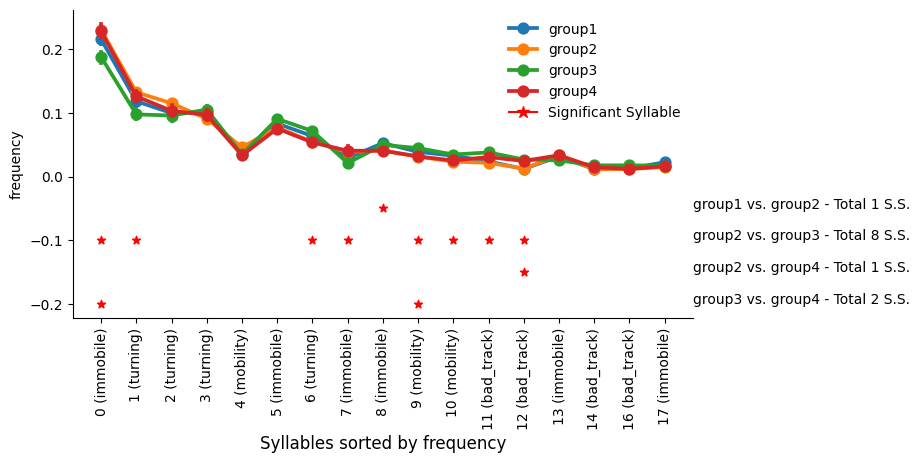

In [26]:
from keypoint_moseq.analysis import plot_syll_stats_with_sem

plot_syll_stats_with_sem(stats_df,
                         project_dir, 
                         model_name, 
                         plot_sig = True)


In [ ]:
from keypoint_moseq.analysis_v2 import plot_syll_stats_with_sem_grouped

plot_syll_stats_with_sem_grouped(
    stats_df,
    project_dir,
    model_name,
    save_dir=None,
    plot_sig=True,
    thresh=0.05,
    stat="frequency",
    order="stat",
    num_factors=1,
    group_to_plot="group",
    groups=None,
    ctrl_group=None,
    exp_group=None,
    colors=None,
    join=False,
    figsize=(8, 4),
)

### Label syllables

In [ ]:
kpms.label_syllables(project_dir, model_name, moseq_df)